In [1]:
import tensorflow as tf
print ('TensorFlow Version:{}'.format(tf.__version__))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

TensorFlow Version:2.10.0


In [2]:
(train_image, train_label),(test_image, test_label) = tf.keras.datasets.fashion_mnist.load_data()#从网上搞了很多张im图片
#保存在 C:\Users\雨寂\.keras\datasets\fashion-mnist

4422102/4422102 [==============================] - 3s 1us/step


In [3]:
train_image = train_image/255
test_image = test_image/255 #归一化

In [4]:
train_label_onehot = tf.keras.utils.to_categorical(train_label)
test_label_onehot = tf.keras.utils.to_categorical(test_label)

In [5]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))  #将输入数据扁平化 二维28*28数组->28*28的向量
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dense(10,activation = 'softmax')) #用softmax激活输出概率 概率和为1

model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['acc']
)  #每次运行计算正确率 shift+tap可以看函数默认值参数

history = model.fit(train_image,train_label_onehot,
          epochs=5,
          validation_data=(test_image,test_label_onehot)
         )#用验证集来检验模型

Epoch 1/5
1875/1875 [==============================] - 14s 6ms/step - loss: 0.4896 - acc: 0.8227 - val_loss: 0.4204 - val_acc: 0.8468
Epoch 2/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3657 - acc: 0.8645 - val_loss: 0.3851 - val_acc: 0.8586
Epoch 3/5
1875/1875 [==============================] - 10s 6ms/step - loss: 0.3329 - acc: 0.8773 - val_loss: 0.3705 - val_acc: 0.8667
Epoch 4/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.3094 - acc: 0.8850 - val_loss: 0.3841 - val_acc: 0.8592
Epoch 5/5
1875/1875 [==============================] - 12s 7ms/step - loss: 0.2921 - acc: 0.8919 - val_loss: 0.3503 - val_acc: 0.8716


<function matplotlib.pyplot.legend(*args, **kwargs)>

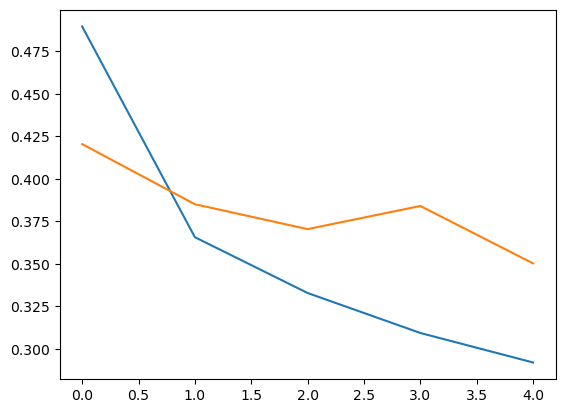

In [6]:
plt.plot(history.epoch, history.history.get('loss'),label='loss')
plt.plot(history.epoch, history.history.get('val_loss'),label='val_loss')
plt.legend #有可能产生过拟合

In [7]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))  #将输入数据扁平化 二维28*28数组->28*28的向量
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dropout(0.5)) #添加dropout层，0.5丢弃率
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dropout(0.5))  
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dropout(0.5))  
model.add(tf.keras.layers.Dense(10,activation = 'softmax')) #用softmax激活输出概率 概率和为1

model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['acc']
)  #每次运行计算正确率 shift+tap可以看函数默认值参数

history = model.fit(train_image,train_label_onehot,
          epochs=5,
          validation_data=(test_image,test_label_onehot)
         )#用验证集来检验模型

Epoch 1/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.8845 - acc: 0.6733 - val_loss: 0.5152 - val_acc: 0.8107
Epoch 2/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.6227 - acc: 0.7785 - val_loss: 0.4740 - val_acc: 0.8287
Epoch 3/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5707 - acc: 0.7993 - val_loss: 0.4538 - val_acc: 0.8397
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5426 - acc: 0.8094 - val_loss: 0.4401 - val_acc: 0.8441
Epoch 5/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5322 - acc: 0.8131 - val_loss: 0.4311 - val_acc: 0.8458


In [8]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               100480    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               16512     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 128)               16512     
                                                                 
 dropout_2 (Dropout)         (None, 128)              

<function matplotlib.pyplot.legend(*args, **kwargs)>

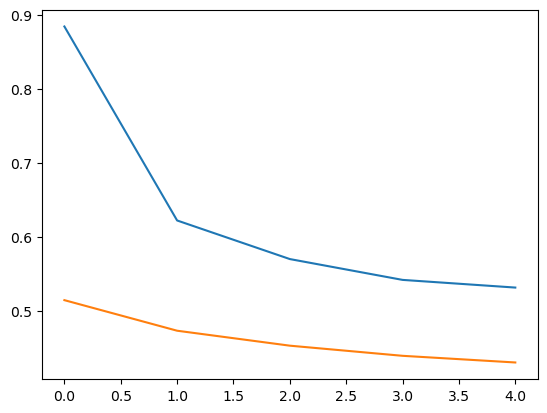

In [9]:
plt.plot(history.epoch, history.history.get('loss'),label='loss')
plt.plot(history.epoch, history.history.get('val_loss'),label='val_loss')
plt.legend 

<function matplotlib.pyplot.legend(*args, **kwargs)>

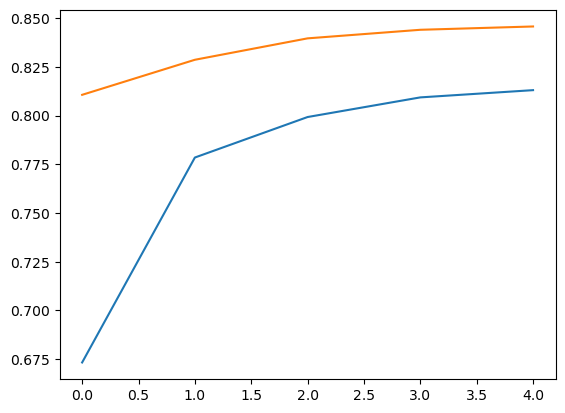

In [10]:
plt.plot(history.epoch, history.history.get('acc'),label='acc')
plt.plot(history.epoch, history.history.get('val_acc'),label='val_acc')
plt.legend 